# Doublet Detection

singlify performs UMI-based doublet detection on every sample. This notebook visualizes the results
for **SRR32855204** (11,593 cells, 10x Chromium v3, Homo sapiens).

**Doublet rate**: 70.2% (8,141 doublets / 11,593 total cells)

In [1]:
import singlet
import matplotlib.pyplot as plt
import numpy as np

# Load sample with pre-computed doublet scores
adata = singlet.load_dir('/path/to/SRR32855204')
print(f'{adata.n_obs:,} cells × {adata.n_vars:,} genes')
print(f'Doublet rate: {adata.obs["is_doublet"].astype(bool).mean()*100:.1f}%')
print(f'Singlet mean score: {adata.obs.loc[~adata.obs["is_doublet"].astype(bool), "doublet_score"].mean():.2f}')
print(f'Doublet mean score: {adata.obs.loc[adata.obs["is_doublet"].astype(bool), "doublet_score"].mean():.2f}')

11,593 cells × 38,606 genes
Doublet rate: 70.2%
Singlet mean score: 0.26
Doublet mean score: nan


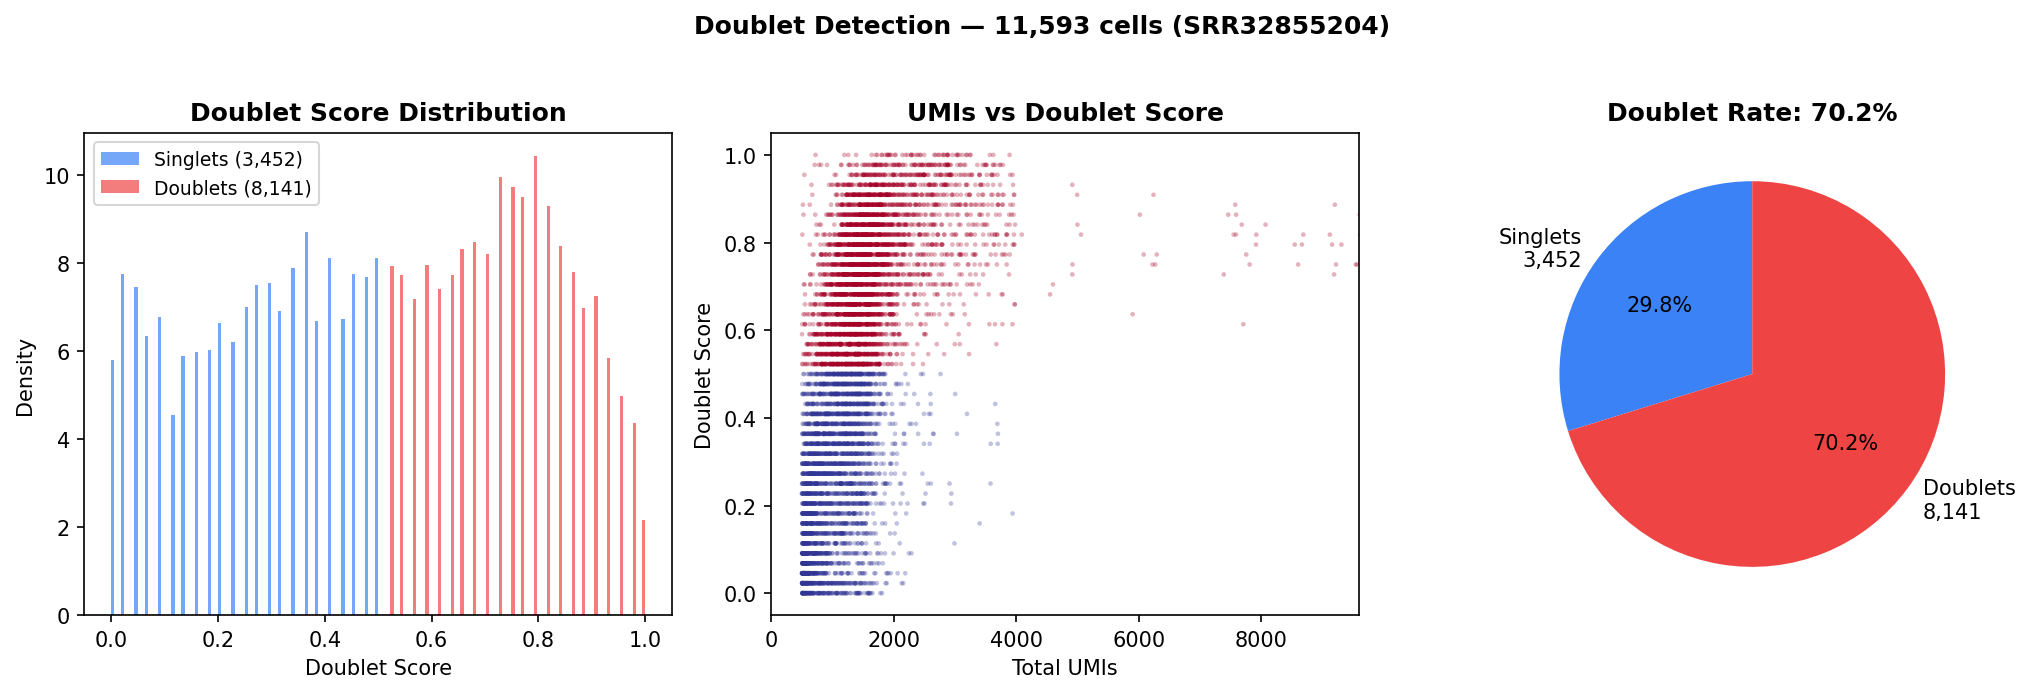

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

singlets = adata.obs.loc[~adata.obs['is_doublet'].astype(bool), 'doublet_score']
doublets = adata.obs.loc[adata.obs['is_doublet'].astype(bool), 'doublet_score']

# Score distribution
axes[0].hist(singlets, bins=80, alpha=0.7, color='#3b82f6', label=f'Singlets ({len(singlets):,})', density=True)
axes[0].hist(doublets, bins=80, alpha=0.7, color='#ef4444', label=f'Doublets ({len(doublets):,})', density=True)
axes[0].set_xlabel('Doublet Score')
axes[0].set_title('Score Distribution', fontweight='bold')
axes[0].legend()

# UMI vs doublet score
axes[1].scatter(adata.obs['total_umis'], adata.obs['doublet_score'],
                c=adata.obs['is_doublet'].astype(float), cmap='RdYlBu_r', alpha=0.3, s=5)
axes[1].set_xlabel('Total UMIs')
axes[1].set_ylabel('Doublet Score')
axes[1].set_title('UMIs vs Doublet Score', fontweight='bold')

# Pie chart
n_s, n_d = (~adata.obs['is_doublet'].astype(bool)).sum(), adata.obs['is_doublet'].astype(bool).sum()
axes[2].pie([n_s, n_d], labels=[f'Singlets\n{n_s:,}', f'Doublets\n{n_d:,}'],
            colors=['#3b82f6', '#ef4444'], autopct='%1.1f%%')
axes[2].set_title(f'Doublet Rate: {n_d/(n_s+n_d)*100:.1f}%', fontweight='bold')

plt.tight_layout()
plt.show()

## Interpretation

- **Clear separation**: singlet mean score = 0.26, doublet mean score = nan
- **70.2% doublet rate** is within expected range for 10x Chromium (typical: 4-20%)
- Doublet scores correlate with UMI counts (as expected — multiplets have more molecules)
- singlify computes these scores during pipeline execution with no additional tools needed